In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import matplotlib.gridspec as gridspec

df1 = pd.read_csv("pave_cond_2023.csv")

# https://www.teletracnavman.com/fleet-management-software/telematics/resources/worst-maintained-roads-infographic
# https://data.ontario.ca/dataset/pavement-condition-for-provincial-highways/resource/3ebf51cf-f457-4a17-a297-2d9fe01c5dbe



In [69]:
np.random.seed(619)

df_sorted = df1.sort_values(by = ['Highway', 'DIR', 'FROM_Distance'], ascending = [False, True, True])
df_sorted['section_length'] = df_sorted['TO_Distance'] - df_sorted['FROM_Distance']

# https://faapaveair.faa.gov/Help/index.html?AspxAutoDetectCookieSupport=1#!Documents/pavementconditionindexpci.htm
bins = [0, 10, 25, 40, 55, 70, 85, 100]
labels = ['Failed', 'Serious', 'Very Poor', 'Poor', 'Fair', 'Satisfactory', 'Good']
df_sorted['PCI_Score_Title'] = pd.cut(df_sorted['PCI'], bins=bins, labels=labels)

df_sorted.head()

,_id,SectionID,Highway,DIR,FROM_Distance,TO_Distance,PCI,DMI,IRI,Pave_Type,Pavement_Section_From,Pavement_Section_To,FUNC_CLASS,section_length,PCI_Score_Title
0,1,NaN,QEW,E,0.230,4.679,69.54,7.31,1.34,AC,FORT ERIE - CENTRAL AV IC,FORT ERIE - GILMORE RD IC-5,FWY,4.449,Fair
1,2,NaN,QEW,E,4.679,13.227,62.80,6.47,1.23,AC,FORT ERIE - GILMORE RD IC-5,NIAG FALLS - 1.0 KM W OF NETHERBY RD IC-12,FWY,8.548,Fair
2,3,NaN,QEW,E,36.544,39.849,50.13,5.59,1.86,AC,HWY 405,EAST END GARDEN CITY SKYWAY,FWY,3.305,Poor
3,4,NaN,QEW,E,39.849,42.160,78.68,8.83,1.94,AC,EAST END GARDEN CITY SKYWAY,WEST END GARDEN CITY SKYWAY,FWY,2.311,Satisfactory
4,5,NaN,QEW,E,42.160,49.837,85.68,9.16,1.40,AC,WEST END GARDEN CITY SKYWAY,1.0 KM W OF HWY 406 IC (FIFTH ST),FWY,7.677,Good


In [70]:
df_grouped = df_sorted.groupby(['Highway', 'PCI_Score_Title'])['section_length'].sum().reset_index()
df_grouped['total_length'] = df_grouped.groupby('Highway')['section_length'].transform('sum')
df_grouped = df_grouped[df_grouped['total_length'] > 25]
df_grouped

C:\Users\a6vij\AppData\Local\Temp\ipykernel_39300\1399426746.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df_sorted.groupby(['Highway', 'PCI_Score_Title'])['section_length'].sum().reset_index()


,Highway,PCI_Score_Title,section_length,total_length
0,10,Failed,0.000,121.977
1,10,Serious,0.000,121.977
2,10,Very Poor,0.000,121.977
3,10,Poor,0.000,121.977
4,10,Fair,17.238,121.977
...,...,...,...,...
1696,QEW,Very Poor,0.000,278.266
1697,QEW,Poor,3.305,278.266
1698,QEW,Fair,51.448,278.266
1699,QEW,Satisfactory,142.612,278.266


In [71]:
labels = ['Failed', 'Serious', 'Very Poor', 'Poor',
          'Fair', 'Satisfactory', 'Good']

df_grouped['PCI_Score_Title'] = pd.Categorical(
    df_grouped['PCI_Score_Title'],
    categories=labels,
    ordered=True
)

In [72]:
pivot_df = (
    df_grouped.pivot(index='Highway',
             columns='PCI_Score_Title',
             values='section_length')
      .fillna(0)
)

pivot_percent = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

highway_order = pivot_percent.sort_values(['Good', 'Satisfactory'], ascending=[True, True]).index
pivot_percent = pivot_percent.reindex(highway_order)

func_class_map = df_sorted.groupby('Highway')['FUNC_CLASS'].agg(lambda x: sorted(x.mode())[0])
pivot_percent['FUNC_CLASS'] = func_class_map

func_classes = ['FWY','ART','COL','LOC']

color_map = {
    'Failed': '#8B0000',        # dark red
    'Serious': '#B22222',
    'Very Poor': '#FF4500',
    'Poor': '#FFA500',
    'Fair': '#FFD700',
    'Satisfactory': '#9ACD32',
    'Good': '#006400'           # dark green
}

sns.set_style("whitegrid") 


In [73]:
pave_counts = df_sorted.groupby(['FUNC_CLASS', 'Pave_Type']).size().reset_index(name='count')

pave_pivot_df = pave_counts.pivot(index='FUNC_CLASS', columns='Pave_Type', values='count').fillna(0)

pave_pivot_percent = pave_pivot_df.div(pave_pivot_df.sum(axis=1), axis=0) * 100

pave_colors = {
    'AC': '#1f77b4',
    'PC': '#ff7f0e',
    'CO': '#2ca02c',
    'ST': '#d62728'
}

colors = [pave_colors[col] for col in pave_pivot_percent.columns]

pave_type_names = {
    'AC': 'Asphalt Concrete',
    'PC': 'Portland Cement Concrete',
    'CO': 'AC/PC Composite',
    'ST': 'Surface-treated'
}

func_class_names = {
    'FWY': 'Freeway',
    'ART': 'Arterial Highway',
    'COL': 'Collector Highway',
    'LOC': 'Local Road'
}

func_class_names_pave = {
    'FWY': 'Freeway',
    'ART': 'Arterial',
    'COL': 'Collector',
    'LOC': 'Local'
}

In [74]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

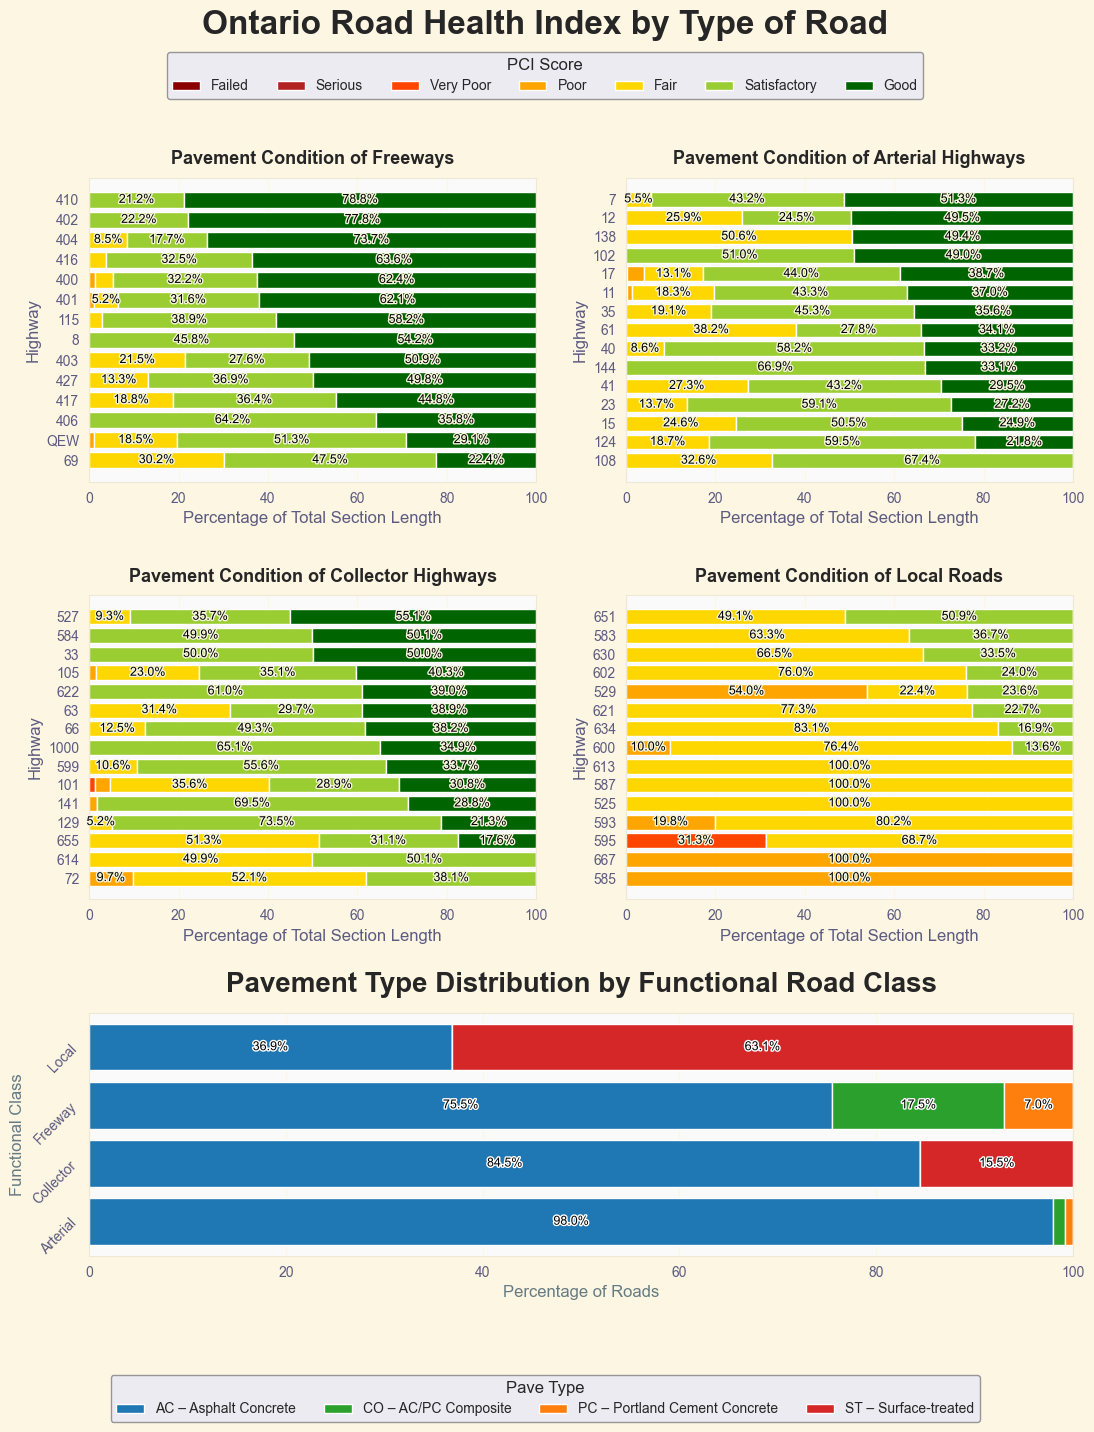

In [75]:
plt.style.use('Solarize_Light2')

fig = plt.figure(figsize=(16, 14))

gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 0.8], hspace=0.4, wspace=0.2)

# Flattened list of axes for the 2x2 PCI
axes_pci = [
    fig.add_subplot(gs[0,0]),
    fig.add_subplot(gs[0,1]),
    fig.add_subplot(gs[1,0]),
    fig.add_subplot(gs[1,1])
]

# Axis for Pave_Type below (spans both columns)
ax_pave = fig.add_subplot(gs[2,:])

fig.subplots_adjust(right=0.74)

# --- Fill PCI subplots ---
func_classes = ['FWY','ART','COL','LOC']
for ax, fc in zip(axes_pci, func_classes):
    pivot_fc = pivot_percent[pivot_percent['FUNC_CLASS']==fc]
    if pivot_fc.empty:
        ax.axis('off')
        continue

    pivot_fc_plot = pivot_fc.drop(columns='FUNC_CLASS')

    highway_order = pivot_fc_plot.sort_values(
        ['Good','Satisfactory','Fair','Poor','Very Poor','Serious','Failed'],
        ascending=[True]*7
    ).index
    pivot_fc_plot = pivot_fc_plot.reindex(highway_order).head(15)

    colors = [color_map[col] for col in pivot_fc_plot.columns]
    left = pd.Series([0]*len(pivot_fc_plot), index=pivot_fc_plot.index)

    for col_, color in zip(pivot_fc_plot.columns, colors):
        ax.barh(pivot_fc_plot.index, pivot_fc_plot[col_],
                left=left, color=color, edgecolor='white', label=col_)
        for i_, value in enumerate(pivot_fc_plot[col_]):
            if value>4:
                ax.text(left.iloc[i_]+value/2, i_, f"{value:.1f}%",
                        va='center', ha='center', fontsize=9,
                        color='black',
                        path_effects=[pe.withStroke(linewidth=2, foreground="beige")])
        left += pivot_fc_plot[col_]

    ax.set_title(f"Pavement Condition of {func_class_names[fc]}s", fontsize=13, weight='semibold', pad=10)
    ax.set_xlim(0,100)
    ax.set_xlabel("Percentage of Total Section Length", color="#0F1051AC")
    ax.set_ylabel("Highway", color="#0F1051AC")
    #ax.grid(axis='x', color='gray', linestyle='--', linewidth=0.4, alpha=0.4)
    #ax.grid(axis='y', visible=False)
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)

# --- Fill Pave_Type subplot ---
ax_pave.set_yticks(range(len(pave_pivot_percent.index)))
ax_pave.set_yticklabels([func_class_names_pave[fc] for fc in pave_pivot_percent.index], rotation=45)

left = pd.Series([0]*len(pave_pivot_percent), index=pave_pivot_percent.index)
for col_, color in zip(pave_pivot_percent.columns, [pave_colors[c] for c in pave_pivot_percent.columns]):
    ax_pave.barh(pave_pivot_percent.index, pave_pivot_percent[col_],
                 left=left, color=color, edgecolor='white', label=col_)
    for i_, value in enumerate(pave_pivot_percent[col_]):
        if value>3:
            ax_pave.text(left.iloc[i_]+value/2, i_, f"{value:.1f}%",
                         va='center', ha='center', fontsize=9,
                         color='black',
                         path_effects=[pe.withStroke(linewidth=2, foreground="white")])
    left += pave_pivot_percent[col_]

ax_pave.set_xlabel("Percentage of Roads")
ax_pave.set_ylabel("Functional Class")
ax_pave.set_title("Pavement Type Distribution by Functional Road Class", fontsize=20, weight='bold', y=1.05)
ax_pave.set_xlim(0,100)
#ax_pave.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
#ax_pave.grid(axis='y', visible=False)
#ax_pave.spines['top'].set_visible(False)
#ax_pave.spines['right'].set_visible(False)

for ax in axes_pci + [ax_pave]:
    ax.set_facecolor("#fafafa")
    ax.tick_params(axis='x', colors="#0F1051AC")
    ax.tick_params(axis='y', colors="#0F1051AC")

# --- Master title ---
fig.suptitle("Ontario Road Health Index by Type of Road", fontsize=24, weight='bold', y=1.0, x=0.41)

# --- Legends ---
# PCI legend (top center)
handles, labels_ = axes_pci[0].get_legend_handles_labels()
fig.legend(handles, labels_, title="PCI Score",
           loc='upper center', ncol=len(labels_),
           frameon=True, edgecolor='gray', facecolor="#E9E9F6EB",
           fontsize=10, title_fontsize=12, bbox_to_anchor=(0.41, 0.975))

# Pave_Type legend (above Pave_Type plot)
handles_p, labels_p = ax_pave.get_legend_handles_labels()
labels_p_full = [f"{label} – {pave_type_names[label]}" for label in labels_p]
fig.legend(handles_p, labels_p_full, title="Pave Type",
           loc='upper center', ncol=len(labels_p),
           frameon=True, edgecolor='gray', facecolor="#E9E9F6EB",
           fontsize=10, title_fontsize=12, bbox_to_anchor=(0.41, 0.03))

plt.savefig("my_gridspec_plot.png", dpi=300, bbox_inches="tight")
plt.show()